In [4]:
from google.colab import files

print("Step 1: Upload Fake.csv")
uploaded1 = files.upload()

print("\nStep 2: Upload True.csv")
uploaded2 = files.upload()

print("\n✅ Both files uploaded!")

Step 1: Upload Fake.csv


Saving Fake.csv to Fake (2).csv

Step 2: Upload True.csv


Saving True.csv to True.csv

✅ Both files uploaded!


In [ ]:
import pandas as pd
import numpy as np

# Load both files
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

print("Fake.csv columns:", list(fake_df.columns))
print("True.csv columns:", list(true_df.columns))
print(f"\nFake news rows: {len(fake_df)}")
print(f"Real news rows: {len(true_df)}")

# Add label column — Fake=0, Real=1
fake_df['label'] = 0
true_df['label'] = 1

# Combine both
df = pd.concat([fake_df, true_df], ignore_index=True)


# Rename if needed
df = df[['title', 'text', 'author' if 'author' in df.columns else 'subject', 'label']].copy()

# Add id column
df.insert(0, 'id', range(1, len(df)+1))

# Rename 
df.columns = ['id', 'title', 'text', 'author', 'label']

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n✅ Dataset created with exact synopsis columns!")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFake(0): {df['label'].value_counts()[0]} | Real(1): {df['label'].value_counts()[1]}")
print("\nFirst 5 rows:")
print(df[['id','title','label']].head())

Fake.csv columns: ['title', 'text', 'subject', 'date']
True.csv columns: ['title', 'text', 'subject', 'date']

Fake news rows: 23481
Real news rows: 21417

✅ Dataset created with exact synopsis columns!
Total rows: 44898
Columns: ['id', 'title', 'text', 'author', 'label']

Fake(0): 23481 | Real(1): 21417

First 5 rows:
      id                                              title  label
0  22217  Ben Stein Calls Out 9th Circuit Court: Committ...      0
1  27918  Trump drops Steve Bannon from National Securit...      1
2  25008  Puerto Rico expects U.S. to lift Jones Act shi...      1
3   1378   OOPS: Trump Just Accidentally Confirmed He Le...      0
4  32477  Donald Trump heads for Scotland to reopen a go...      1


In [6]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords + Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Handle missing values
df['text']   = df['text'].fillna('')
df['title']  = df['title'].fillna('')
df['author'] = df['author'].fillna('unknown')

# Combine title + text for better prediction
df['combined'] = df['title'] + ' ' + df['text']

# Clean the combined column
print("Cleaning text... this may take 1-2 minutes...")
df['cleaned'] = df['combined'].apply(clean_text)

print("✅ Text Cleaning Done!")
print("\nSample cleaned text:")
print(df['cleaned'].iloc[0][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Cleaning text... this may take 1-2 minutes...
✅ Text Cleaning Done!

Sample cleaned text:
ben stein call th circuit court committed coup dtat constitution st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump 


/tmp/ipykernel_3195/2969457577.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


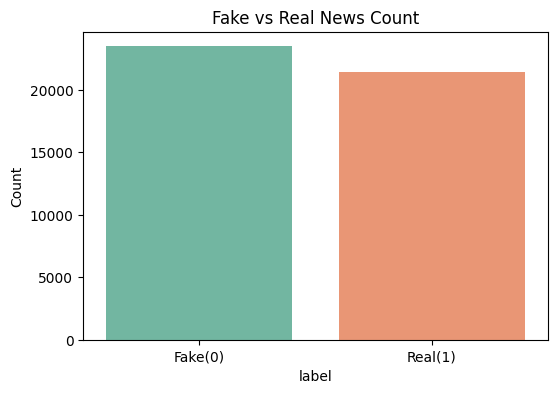

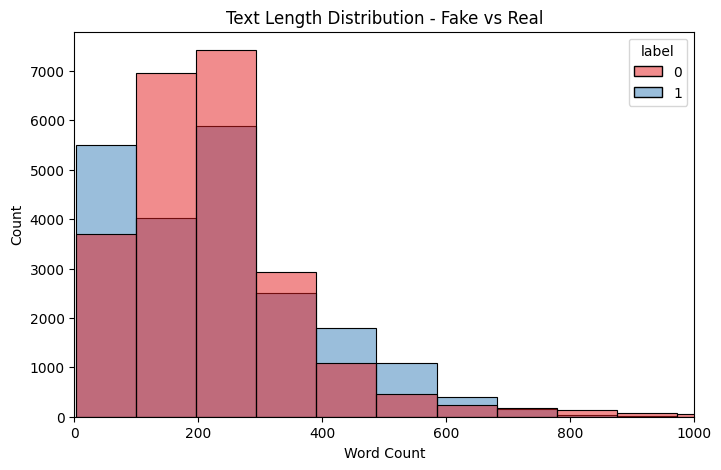

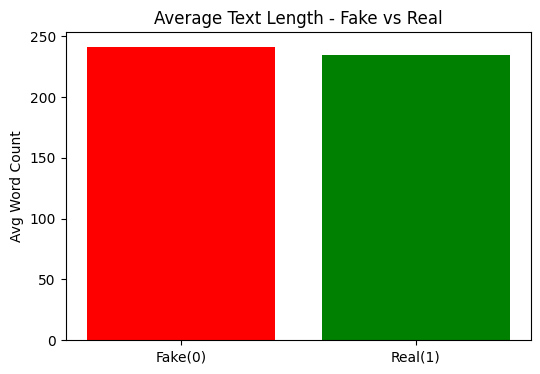

✅ EDA Done!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph 1: Fake vs Real count
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Fake vs Real News Count')
plt.xticks([0,1], ['Fake(0)', 'Real(1)'])
plt.ylabel('Count')
plt.show()

# Graph 2: Text length distribution
df['text_length'] = df['cleaned'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, palette='Set1')
plt.title('Text Length Distribution - Fake vs Real')
plt.xlabel('Word Count')
plt.xlim(0, 1000)
plt.show()

# Graph 3: Average text length
avg_len = df.groupby('label')['text_length'].mean()
plt.figure(figsize=(6,4))
plt.bar(['Fake(0)', 'Real(1)'], avg_len.values, color=['red','green'])
plt.title('Average Text Length - Fake vs Real')
plt.ylabel('Avg Word Count')
plt.show()

print("✅ EDA Done!")

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# TF-IDF Feature Extraction
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['cleaned'])
y = df['label']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ TF-IDF Feature Extraction Done!")
print(f"Total features: {X.shape[1]}")
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

✅ TF-IDF Feature Extraction Done!
Total features: 5000
Train size: 35918 | Test size: 8980


=== MODEL ACCURACY COMPARISON ===

Training Naive Bayes...
Naive Bayes               → 94.34%

Training Logistic Regression...
Logistic Regression       → 98.78%

Training SVM...
SVM                       → 99.57%

Training Random Forest...
Random Forest             → 99.72%



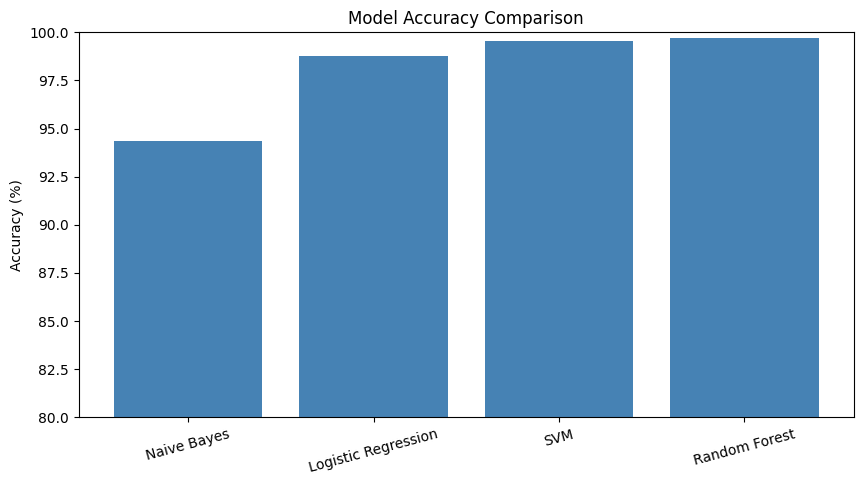

✅ Best Model: Random Forest (99.72%)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# All 4 models 
models = {
    'Naive Bayes':        MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM':                LinearSVC(),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42)
}

print("=== MODEL ACCURACY COMPARISON ===\n")
results_dict = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results_dict[name] = acc
    trained_models[name] = model
    print(f"{name:25s} → {acc*100:.2f}%\n")

# Bar chart
plt.figure(figsize=(10,5))
plt.bar(results_dict.keys(), [v*100 for v in results_dict.values()], color='steelblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(80, 100)
plt.xticks(rotation=15)
plt.show()

# Best model
best_name = max(results_dict, key=results_dict.get)
print(f"✅ Best Model: {best_name} ({results_dict[best_name]*100:.2f}%)")

=== RANDOM FOREST - FULL REPORT ===

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4710
        Real       1.00      1.00      1.00      4270

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



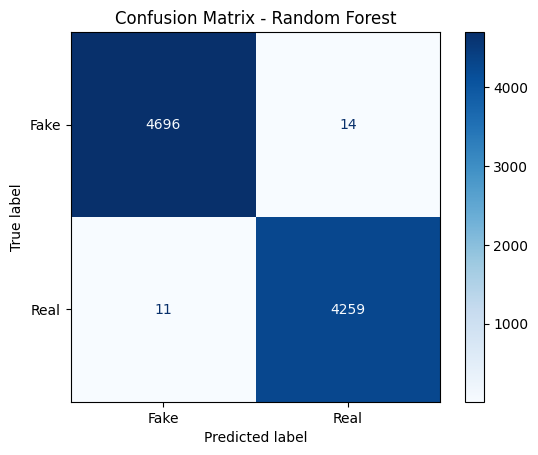

✅ Evaluation Done!


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)

print(f"=== {best_name.upper()} - FULL REPORT ===\n")
print(classification_report(y_test, y_pred, target_names=['Fake','Real']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fake','Real']).plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

print("✅ Evaluation Done!")

In [16]:
def predict_news(news_text):
    cleaned = clean_text(news_text)
    vectorized = tfidf.transform([cleaned])
    prediction = best_model.predict(vectorized)[0]
    return "🟢 REAL News" if prediction == 1 else "🔴 FAKE News"

# Pick real samples directly from dataset
fake_sample = df[df['label'] == 0]['combined'].iloc[0]
real_sample = df[df['label'] == 1]['combined'].iloc[0]
fake_sample2 = df[df['label'] == 0]['combined'].iloc[5]

articles = [
    ("Should be FAKE", fake_sample),
    ("Should be REAL", real_sample),
    ("Should be FAKE", fake_sample2),
]

print("=== NEWS PREDICTION RESULTS ===\n")
for expected, article in articles:
    result = predict_news(article)
    print(f"Expected  : {expected}")
    print(f"Prediction: {result}")
    print(f"Article   : {article[:80]}...")
    print()


=== NEWS PREDICTION RESULTS ===

Expected  : Should be FAKE
Prediction: 🔴 FAKE News
Article   : Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Con...

Expected  : Should be REAL
Prediction: 🟢 REAL News
Article   : Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U...

Expected  : Should be FAKE
Prediction: 🔴 FAKE News
Article   : WHERE’S HILLARY? CLINTON SPOTTED Dining Alone  ...

